# Sales Forecasting using ARIMA, SARIMA and Machine Learning Models

## Objective

The objective of this project is to forecast retail sales using classical time series models and machine learning techniques. The project compares ARIMA, SARIMA, Random Forest, and XGBoost models to identify the most effective forecasting approach.

In [9]:
import pandas as pd

train = pd.read_csv("train.csv")
store = pd.read_csv("store.csv")

# Data Cleaning

The dataset was imported and inspected for missing values, incorrect data types, and duplicate observations. The Date column was converted into datetime format to enable time series analysis. Clean and properly formatted data is essential for accurate forecasting.

In [10]:
train.head()
train.info()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308219 entries, 0 to 308218
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Store          308219 non-null  int64  
 1   DayOfWeek      308218 non-null  float64
 2   Date           308218 non-null  object 
 3   Sales          308218 non-null  float64
 4   Customers      308218 non-null  float64
 5   Open           308218 non-null  float64
 6   Promo          308218 non-null  float64
 7   StateHoliday   308218 non-null  object 
 8   SchoolHoliday  308218 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 21.2+ MB


,0
Store,0
DayOfWeek,1
Date,1
Sales,1
Customers,1
Open,1
Promo,1
StateHoliday,1
SchoolHoliday,1


In [11]:
#Convert date:
train['Date'] = pd.to_datetime(train['Date'])

# Creating Time Series Data

Daily sales were aggregated by date to create a univariate time series. This transformation allows the application of forecasting techniques such as ARIMA and SARIMA.

In [12]:
#Create the time series:
sales_ts = train.groupby('Date')['Sales'].sum()

In [24]:
sales_ts.describe()
sales_ts.isna().sum()
sales_ts.shape

(289,)

# Exploratory Data Analysis

Exploratory Data Analysis was performed to understand the distribution and behavior of sales over time. Various visualizations were created to identify trends, seasonal patterns, and unusual observations in the dataset.

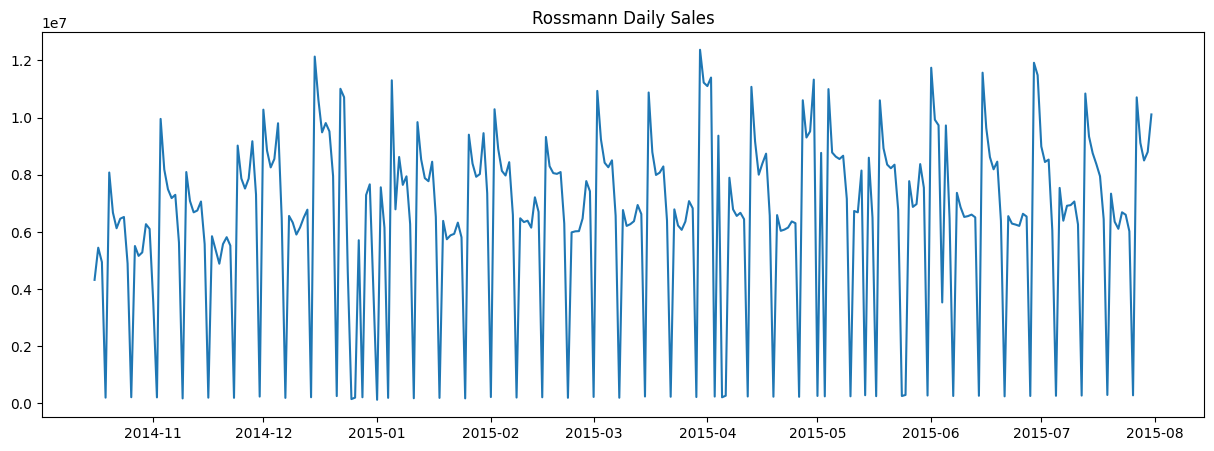

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(sales_ts)
plt.title("Rossmann Daily Sales")
plt.show()

In [15]:
#Check Time Range
print("Start Date:", sales_ts.index.min())
print("End Date:", sales_ts.index.max())

Start Date: 2014-10-16 00:00:00
End Date: 2015-07-31 00:00:00


# Trend Analysis

The sales series was visualized to observe overall movement over time. Trend analysis helps determine whether sales are increasing, decreasing, or remaining stable during the study period.

/tmp/ipykernel_3536/621899404.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales_ts.resample('M').sum()


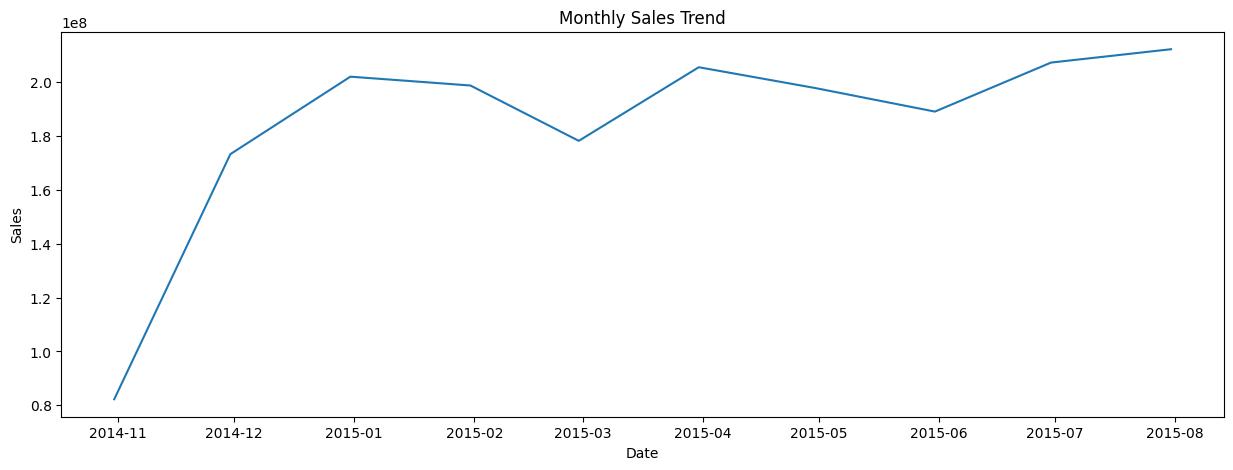

In [16]:
#Monthly Sales Trend
monthly_sales = sales_ts.resample('M').sum()

plt.figure(figsize=(15,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

/tmp/ipykernel_3536/3846103981.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_sales = sales_ts.resample('Y').sum()


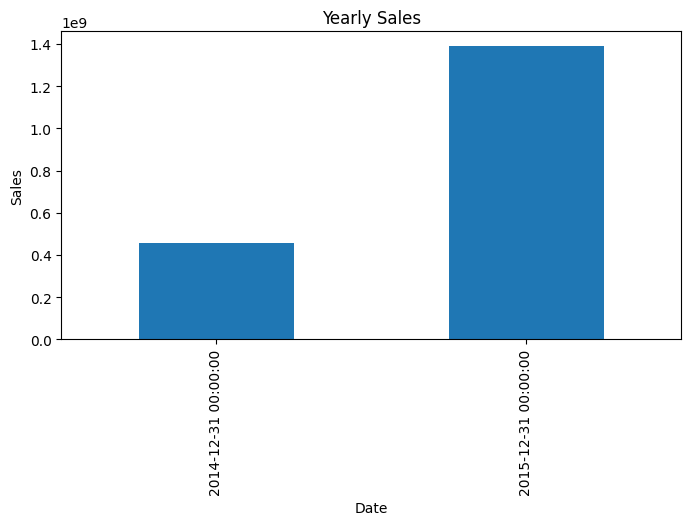

In [52]:
#Year-wise Sales
yearly_sales = sales_ts.resample('Y').sum()

plt.figure(figsize=(8,4))
yearly_sales.plot(kind='bar')
plt.title("Yearly Sales")
plt.ylabel("Sales")
plt.show()

# Distribution of Sales

Histogram and boxplot visualizations were used to examine the distribution of daily sales. This helps identify skewness, variability, and potential outliers present in the data.

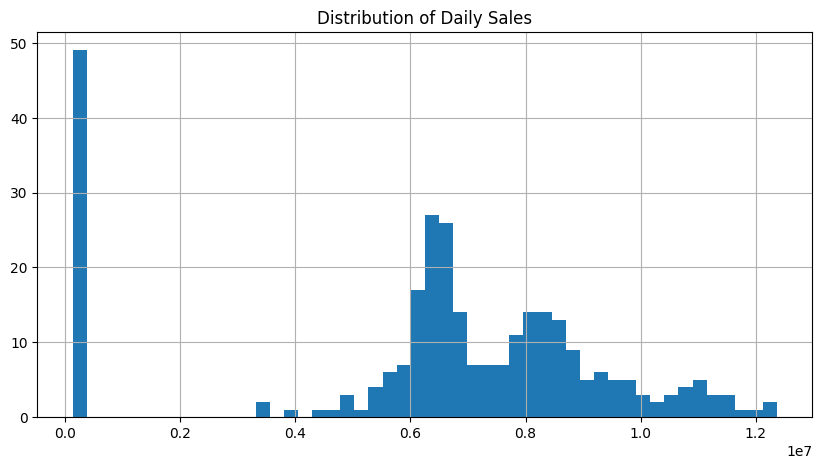

In [19]:
#Distribution of Sales
plt.figure(figsize=(10,5))
sales_ts.hist(bins=50)
plt.title("Distribution of Daily Sales")
plt.show()

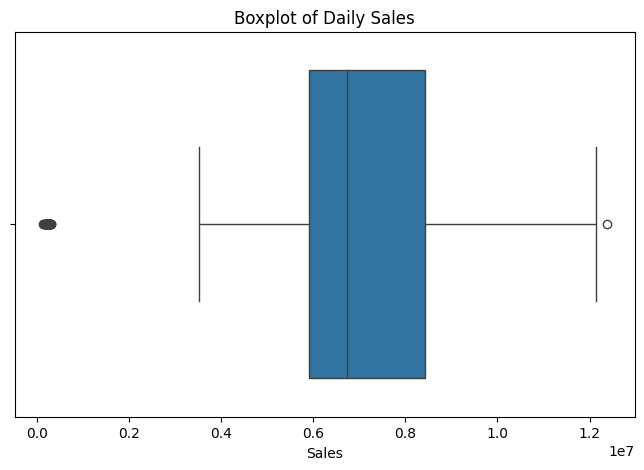

In [21]:
#Boxplot
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=sales_ts)
plt.title("Boxplot of Daily Sales")
plt.show()

# Time Series Decomposition

The time series was decomposed into Trend, Seasonal, and Residual components. This step helps understand the underlying structure of the series and detect recurring seasonal patterns.

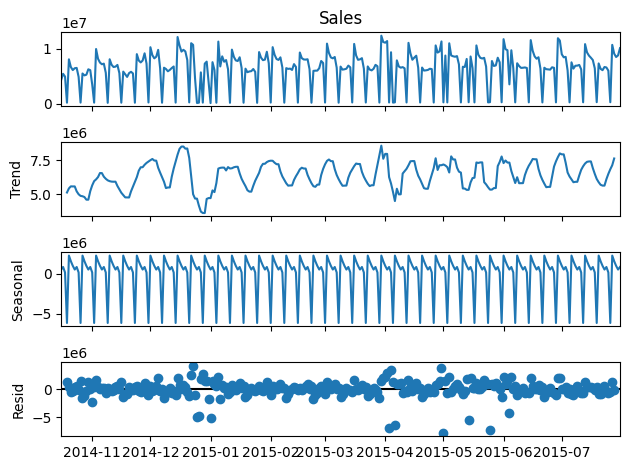

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    sales_ts,
    model='additive',
    period=7
)

decomposition.plot()
plt.show()

### Observation

The decomposition results indicate a clear weekly seasonal pattern in sales. The trend component shows moderate fluctuations, while residuals are centered around zero, suggesting that most systematic variation has been captured.

# Augmented Dickey-Fuller (ADF) Test

The ADF test was performed to determine whether the sales series is stationary. Stationarity is an important assumption for ARIMA-based forecasting models.

In [28]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(sales_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print(key, value)

ADF Statistic: -5.03696858864901
p-value: 1.8742848160737815e-05
1% -3.4546223782586534
5% -2.8722253212300277
10% -2.5724638500216264


### Interpretation

The p-value obtained from the ADF test is less than 0.05, indicating that the sales series is stationary. Therefore, differencing is not required before fitting ARIMA and SARIMA models.

# ACF and PACF Analysis

Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots were analyzed to determine suitable AR and MA orders for forecasting models.

<Figure size 1000x500 with 0 Axes>

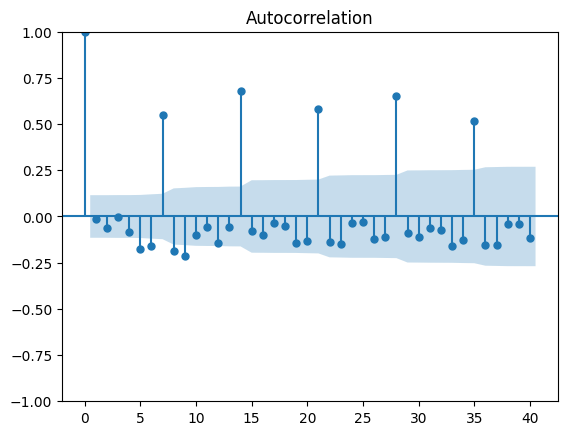

<Figure size 1000x500 with 0 Axes>

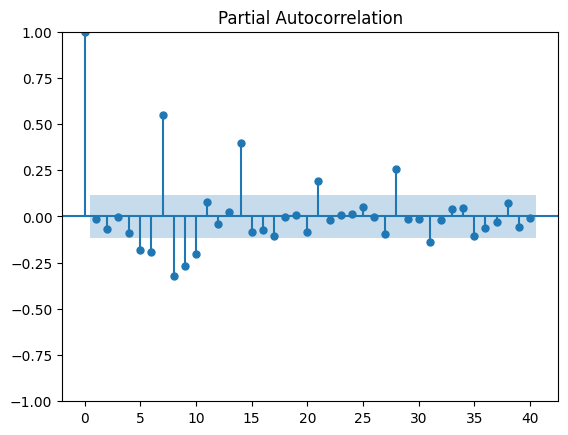

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(10,5))
plot_acf(sales_ts, lags=40)
plt.show()

plt.figure(figsize=(10,5))
plot_pacf(sales_ts, lags=40)
plt.show()

### Observation

Significant spikes are observed at multiples of lag 7, confirming strong weekly seasonality in the sales data. These results support the use of a seasonal forecasting model.

# Baseline Forecast Model

A baseline forecasting model was developed to establish a benchmark for evaluating advanced forecasting models. Future models should outperform this benchmark to justify their use.

In [55]:
naive_pred = test_ts.shift(1)
moving_avg = train_ts.rolling(7).mean()

# ARIMA Model

An ARIMA model was fitted to capture the autocorrelation structure of the stationary sales series. The model serves as a baseline forecasting approach.

In [31]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(sales_ts, order=(1,0,1))
arima_result = arima_model.fit()

print(arima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  289
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -4732.927
Date:                Wed, 10 Jun 2026   AIC                           9473.855
Time:                        12:44:08   BIC                           9488.520
Sample:                    10-16-2014   HQIC                          9479.731
                         - 07-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.392e+06   2.35e+05     27.158      0.000    5.93e+06    6.85e+06
ar.L1         -0.7985      0.095     -8.402      0.000      -0.985      -0.612
ma.L1          0.9157      0.063     14.498      0.0

In [32]:
print("AIC:", arima_result.aic)
print("BIC:", arima_result.bic)

AIC: 9473.854666632882
BIC: 9488.520373385332


### Observation

The ARIMA model captures short-term dependencies in the data but does not explicitly account for seasonal effects.

# SARIMA Model

A SARIMA model was developed to capture both non-seasonal and seasonal patterns present in the sales series. Weekly seasonality was incorporated using a seasonal period of 7 days.

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    sales_ts,
    order=(1,0,1),
    seasonal_order=(1,0,1,7)
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                  289
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -4683.018
Date:                           Wed, 10 Jun 2026   AIC                           9376.037
Time:                                   12:45:04   BIC                           9394.369
Sample:                               10-16-2014   HQIC                          9383.383
                                    - 07-31-2015                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7404      0.264      2.802      0.005       0.222       1.258
ma.L1         -0.4164      0.324     -1.284

In [34]:
print("AIC:", sarima_result.aic)
print("BIC:", sarima_result.bic)

AIC: 9376.036942850656
BIC: 9394.36907629122


### Observation

SARIMA achieved substantially lower AIC and BIC values than ARIMA, indicating a superior fit due to its ability to model weekly seasonal behavior.

# Model Evaluation

The forecasting performance of ARIMA and SARIMA models was evaluated using Mean Absolute Error (MAE), Mean Absolute Percentage Error (MAPE) and Root Mean Squared Error (RMSE)

In [44]:
train_size = int(len(sales_ts) * 0.8)

train_ts = sales_ts[:train_size]
test_ts = sales_ts[train_size:]
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train_ts, order=(1,0,1))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test_ts))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [62]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

arima_mae = mean_absolute_error(test_ts, arima_pred)


arima_mape = mean_absolute_percentage_error(
    test_ts,
    arima_pred
)


arima_rmse = np.sqrt(
    mean_squared_error(
        test_ts,
        arima_pred
    )
)

print(arima_mae)
print(arima_mape)
print(arima_rmse)



2200265.5235010483
3.199099591778099
3046588.749504258


In [46]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_ts,
    order=(1,0,1),
    seasonal_order=(1,0,1,7)
)

sarima_fit = sarima_model.fit()

sarima_pred = sarima_fit.forecast(
    steps=len(test_ts)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [63]:
sarima_mae = mean_absolute_error(
    test_ts,
    sarima_pred
)

sarima_mape = mean_absolute_percentage_error(
    test_ts,
    sarima_pred
)


sarima_rmse = np.sqrt(
    mean_squared_error(
        test_ts,
        sarima_pred
    )
)

print(sarima_mae)
print(sarima_mape)
print(sarima_rmse)

1197844.7152026533
0.2216491175452471
1673164.594133222


### Conclusion

SARIMA outperformed ARIMA by producing lower forecasting errors, demonstrating the importance of incorporating seasonal information into the model.

# Feature Engineering

Lag features, rolling averages, month information, and day-of-week indicators were generated to provide machine learning models with historical sales patterns.

In [64]:
rf_df = sales_ts.reset_index()

rf_df.columns = ['Date', 'Sales']

rf_df['lag_1'] = rf_df['Sales'].shift(1)
rf_df['lag_7'] = rf_df['Sales'].shift(7)
rf_df['lag_14'] = rf_df['Sales'].shift(14)

rf_df['rolling_mean_7'] = rf_df['Sales'].rolling(7).mean()
rf_df['rolling_std_7'] = rf_df['Sales'].rolling(7).std()

rf_df['month'] = rf_df['Date'].dt.month
rf_df['dayofweek'] = rf_df['Date'].dt.dayofweek

rf_df = rf_df.dropna()

rf_df.head()

,Date,Sales,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,month,dayofweek
14,2014-10-30,6271893.0,5285015.0,6463607.0,4324463.0,4.838051e+06,2.120794e+06,10,3
15,2014-10-31,6106412.0,6271893.0,6523289.0,5449686.0,4.778497e+06,2.070849e+06,10,4
16,2014-11-01,3522395.0,6106412.0,4894704.0,4945733.0,4.582453e+06,2.122331e+06,11,5
17,2014-11-02,213741.0,3522395.0,219359.0,204991.0,4.581650e+06,2.124257e+06,11,6
18,2014-11-03,9953793.0,213741.0,5508341.0,8078830.0,5.216715e+06,2.951068e+06,11,0


In [65]:
rf_df.shape

(275, 9)

In [66]:
train_size = int(len(rf_df) * 0.8)

train = rf_df.iloc[:train_size]
test = rf_df.iloc[train_size:]

X_train = train.drop(['Date','Sales'], axis=1)
y_train = train['Sales']

X_test = test.drop(['Date','Sales'], axis=1)
y_test = test['Sales']

print(X_train.shape)
print(X_test.shape)

(220, 7)
(55, 7)


# Random Forest Regressor

A Random Forest model was trained using engineered time series features. Random Forest is capable of capturing nonlinear relationships and complex interactions among predictors.

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [67]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mape = mean_absolute_percentage_error(
    y_test,
    rf_pred
)


rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

print("RF MAE :", rf_mae)
print("RF MAPE:", rf_mape)
print("RF RMSE:", rf_rmse)

RF MAE : 754922.4839999998
RF MAPE: 0.4817314421793813
RF RMSE: 1084303.224289393


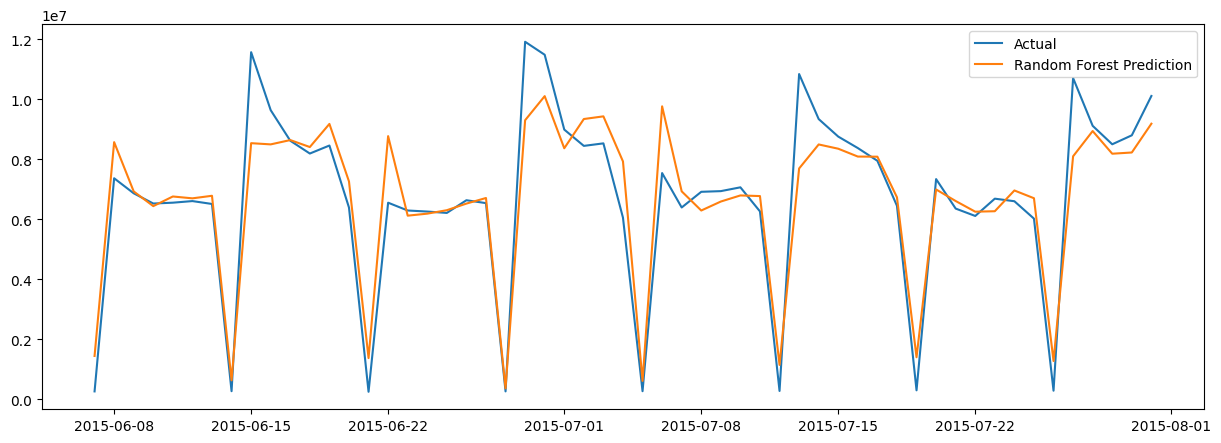

In [68]:
plt.figure(figsize=(15,5))

plt.plot(
    test['Date'],
    y_test,
    label='Actual'
)

plt.plot(
    test['Date'],
    rf_pred,
    label='Random Forest Prediction'
)

plt.legend()
plt.show()

# XGBoost Regressor

An XGBoost model was developed as an advanced ensemble learning method. Its forecasting performance was compared with Random Forest and statistical models.

In [41]:
!pip install xgboost
from xgboost import XGBRegressor

In [42]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [69]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)
xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_pred
)


xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

print("XGB MAE :", xgb_mae)
print("XGB MAPE:", xgb_mape)
print("XGB RMSE:", xgb_rmse)

XGB MAE : 834060.7107954546
XGB MAPE: 0.20777149925863705
XGB RMSE: 1252846.1105857822


# Model Comparison

All forecasting models were compared using MAE, RMSE, and MAPE. Lower values indicate better forecasting performance.

In [70]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'Random Forest', 'XGBoost'],
    'MAE': [
        arima_mae,
        sarima_mae,
        rf_mae,
        xgb_mae
    ],
    'RMSE': [
        arima_rmse,
        sarima_rmse,
        rf_rmse,
        xgb_rmse
    ],
    'MAPE': [
        arima_mape,
        sarima_mape,
        rf_mape,
        xgb_mape
    ]
})

comparison
comparison.round(4)

,Model,MAE,RMSE,MAPE
0,ARIMA,2.200266e+06,3.046589e+06,3.1991
1,SARIMA,1.197845e+06,1.673165e+06,0.2216
2,Random Forest,7.549225e+05,1.084303e+06,0.4817
3,XGBoost,8.340607e+05,1.252846e+06,0.2078


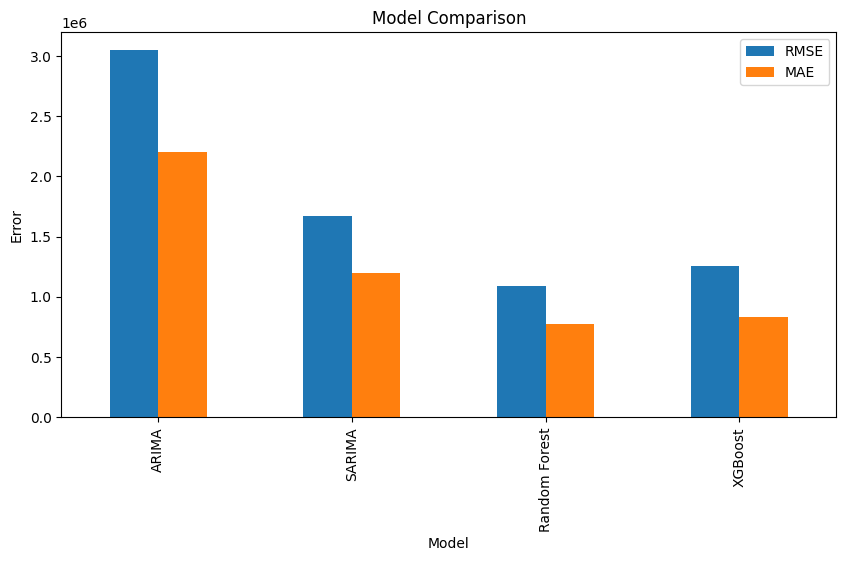

In [54]:
import matplotlib.pyplot as plt

comparison.set_index('Model')[['RMSE','MAE']].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Model Comparison')
plt.ylabel('Error')
plt.show()

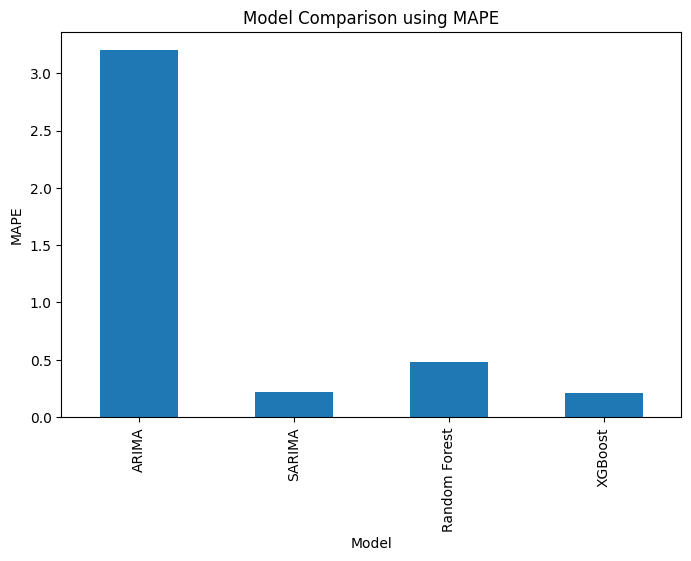

In [72]:
comparison.set_index('Model')['MAPE'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Comparison using MAPE')
plt.ylabel('MAPE')
plt.show()

### Result

Among all forecasting models, Random Forest achieved the lowest MAE and RMSE values, indicating the best overall forecasting performance. SARIMA outperformed ARIMA by effectively capturing weekly seasonal patterns in the sales data, while XGBoost also produced competitive results.

# Feature Importance Analysis

Feature importance was analyzed to identify the variables that contribute most to forecasting performance.

In [73]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

          Feature  Importance
6       dayofweek    0.533288
1           lag_7    0.143427
4   rolling_std_7    0.093885
3  rolling_mean_7    0.088771
0           lag_1    0.068665
2          lag_14    0.062657
5           month    0.009306


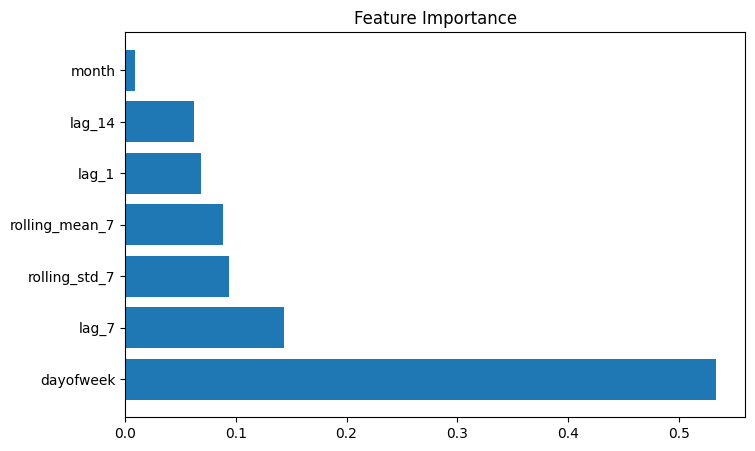

In [74]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.show()

### Observation

Day of Week emerged as the most influential predictor, followed by Lag-7 sales and Rolling Mean. This confirms that weekly seasonal patterns play a critical role in determining future sales.

# Sales Forecast for the Next 90 Days

The selected forecasting model was used to predict future sales for the next 90 days. Forecasted values help estimate future demand and support business planning.

In [75]:
#Since SARIMA is currently the  strongest statistical model.
forecast = sarima_result.get_forecast(steps=90)

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int()

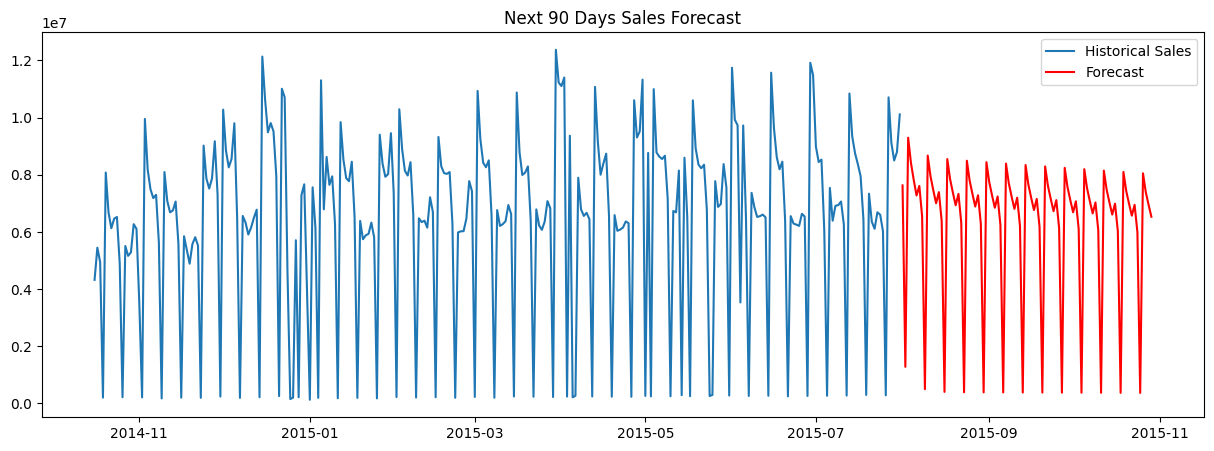

In [76]:
plt.figure(figsize=(15,5))

plt.plot(
    sales_ts.index,
    sales_ts,
    label='Historical Sales'
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label='Forecast',
    color='red'
)

plt.legend()
plt.title("Next 90 Days Sales Forecast")
plt.show()

### Observation

The forecast maintains a stable sales pattern with recurring weekly fluctuations. No major upward or downward trend is expected over the forecast horizon.


# Business Insights

1. Weekly seasonality is the strongest driver of sales.
2. Sales from the previous week strongly influence future demand.
3. Recent sales trends provide valuable forecasting information.
4. Monthly effects are relatively weak compared to weekly patterns.
5. Random Forest delivered the best predictive performance among all models evaluated.

# Conclusion

This project compared classical time series forecasting techniques (ARIMA and SARIMA) with machine learning approaches (Random Forest and XGBoost). The results show that incorporating seasonality and historical sales patterns significantly improves forecasting accuracy. Random Forest achieved the best overall performance, while SARIMA was the strongest statistical forecasting model.